In [1]:
import pandas as pd
from sqlalchemy import create_engine

server = '.'
database = 'Northwind'

engine = create_engine(
    f'mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes'
)

In [2]:
test_query = "SELECT TOP 5 * FROM Customers"
df_test = pd.read_sql(test_query, engine)
df_test

c:\Users\dharm\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1135.8'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


,CustomerID,CompanyName,ContactName,ContactTitle,Address,City,Region,PostalCode,Country,Phone,Fax
0,ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,Berlin,None,12209,Germany,030-0074321,030-0076545
1,ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Avda. de la Constitución 2222,México D.F.,None,05021,Mexico,(5) 555-4729,(5) 555-3745
2,ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mataderos 2312,México D.F.,None,05023,Mexico,(5) 555-3932,None
3,AROUT,Around the Horn,Thomas Hardy,Sales Representative,120 Hanover Sq.,London,None,WA1 1DP,UK,(171) 555-7788,(171) 555-6750
4,BERGS,Berglunds snabbköp,Christina Berglund,Order Administrator,Berguvsvägen 8,Luleå,None,S-958 22,Sweden,0921-12 34 65,0921-12 34 67


In [3]:
master_query = """
SELECT o.OrderDate, cx.CompanyName, e.FirstName + ' ' + e.LastName AS SalesRep,
       p.ProductName, ctg.CategoryName, od.Quantity, od.UnitPrice, od.Discount,
       (od.UnitPrice * od.Quantity) * (1 - od.Discount) AS LineRevenue
FROM Orders o
JOIN Customers cx ON o.CustomerID = cx.CustomerID
JOIN Employees e ON o.EmployeeID = e.EmployeeID
JOIN [Order Details] od ON o.OrderID = od.OrderID
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories ctg ON p.CategoryID = ctg.CategoryID
ORDER BY o.OrderDate
"""

df = pd.read_sql(master_query, engine)
df.head()

,OrderDate,CompanyName,SalesRep,ProductName,CategoryName,Quantity,UnitPrice,Discount,LineRevenue
0,1996-07-04,Vins et alcools Chevalier,Steven Buchanan,Queso Cabrales,Dairy Products,12,14.0,0.0,168.000000
1,1996-07-04,Vins et alcools Chevalier,Steven Buchanan,Singaporean Hokkien Fried Mee,Grains/Cereals,10,9.8,0.0,98.000000
2,1996-07-04,Vins et alcools Chevalier,Steven Buchanan,Mozzarella di Giovanni,Dairy Products,5,34.8,0.0,174.000000
3,1996-07-05,Toms Spezialitäten,Michael Suyama,Tofu,Produce,9,18.6,0.0,167.399994
4,1996-07-05,Toms Spezialitäten,Michael Suyama,Manjimup Dried Apples,Produce,40,42.4,0.0,1696.000000


In [15]:
df['OrderMonth'] = df['OrderDate'].dt.to_period('M')
df.head()

,OrderDate,CompanyName,SalesRep,ProductName,CategoryName,Quantity,UnitPrice,Discount,LineRevenue,OrderMonth
0,1996-07-04,Vins et alcools Chevalier,Steven Buchanan,Queso Cabrales,Dairy Products,12,14.0,0.0,168.000000,1996-07
1,1996-07-04,Vins et alcools Chevalier,Steven Buchanan,Singaporean Hokkien Fried Mee,Grains/Cereals,10,9.8,0.0,98.000000,1996-07
2,1996-07-04,Vins et alcools Chevalier,Steven Buchanan,Mozzarella di Giovanni,Dairy Products,5,34.8,0.0,174.000000,1996-07
3,1996-07-05,Toms Spezialitäten,Michael Suyama,Tofu,Produce,9,18.6,0.0,167.399994,1996-07
4,1996-07-05,Toms Spezialitäten,Michael Suyama,Manjimup Dried Apples,Produce,40,42.4,0.0,1696.000000,1996-07


In [16]:
monthly_revenue = df.groupby('OrderMonth')['LineRevenue'].sum()
monthly_revenue

OrderMonth
1996-07     27861.894974
1996-08     25485.274970
1996-09     26381.399973
1996-10     37515.725197
1996-11     45600.044844
1996-12     45239.629696
1997-01     61258.070463
1997-02     38483.634981
1997-03     38547.219996
1997-04     53032.952518
1997-05     53781.290039
1997-06     36362.802532
1997-07     51020.857527
1997-08     47287.670330
1997-09     55629.242485
1997-10     66749.225880
1997-11     43533.809015
1997-12     71398.428598
1998-01     94222.110553
1998-02     99415.287338
1998-03    104854.155029
1998-04    123798.682137
1998-05     18333.630543
Freq: M, Name: LineRevenue, dtype: float64

In [19]:
monthly_revenue = monthly_revenue[monthly_revenue.index < '1998-05']
monthly_revenue

OrderMonth
1996-07     27861.894974
1996-08     25485.274970
1996-09     26381.399973
1996-10     37515.725197
1996-11     45600.044844
1996-12     45239.629696
1997-01     61258.070463
1997-02     38483.634981
1997-03     38547.219996
1997-04     53032.952518
1997-05     53781.290039
1997-06     36362.802532
1997-07     51020.857527
1997-08     47287.670330
1997-09     55629.242485
1997-10     66749.225880
1997-11     43533.809015
1997-12     71398.428598
1998-01     94222.110553
1998-02     99415.287338
1998-03    104854.155029
1998-04    123798.682137
Freq: M, Name: LineRevenue, dtype: float64

In [20]:
monthly_revenue.tail()

OrderMonth
1997-12     71398.428598
1998-01     94222.110553
1998-02     99415.287338
1998-03    104854.155029
1998-04    123798.682137
Freq: M, Name: LineRevenue, dtype: float64

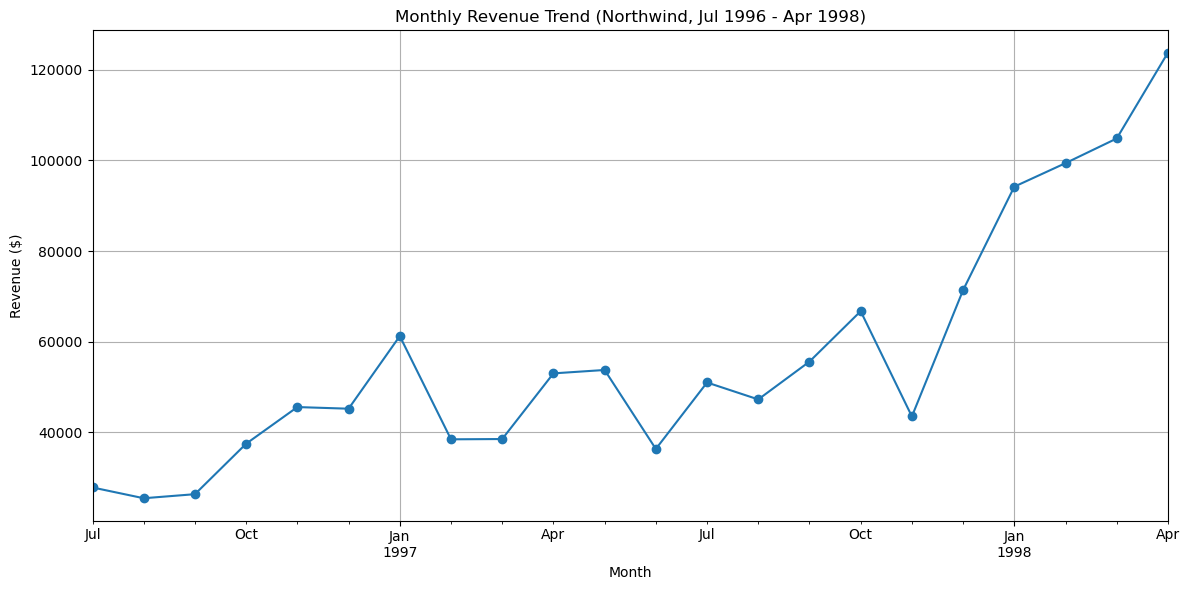

In [21]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind='line', figsize=(12,6), marker='o')
plt.title('Monthly Revenue Trend (Northwind, Jul 1996 - Apr 1998)')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150)
plt.show()


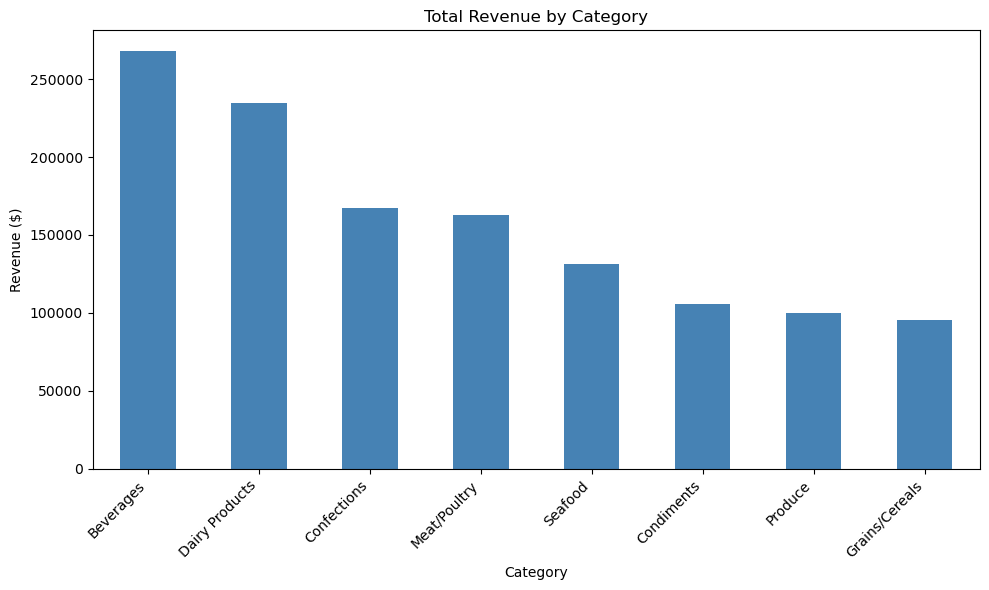

In [31]:
category_revenue = df.groupby('CategoryName')['LineRevenue'].sum().sort_values(ascending=False)

category_revenue.plot(kind='bar', figsize=(10, 6), color='steelblue')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=150)
plt.show()

In [32]:
top3_query = """
WITH ProductSales AS (
    SELECT ctg.CategoryName, p.ProductName,
           SUM((od.UnitPrice * od.Quantity) * (1 - od.Discount)) AS ProductRevenue
    FROM [Order Details] od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories ctg ON p.CategoryID = ctg.CategoryID
    GROUP BY ctg.CategoryName, p.ProductName
),
RankedProducts AS (
    SELECT *,
        RANK() OVER (PARTITION BY CategoryName ORDER BY ProductRevenue DESC) AS RevenueRank
    FROM ProductSales
)
SELECT *
FROM RankedProducts
WHERE RevenueRank <= 3
ORDER BY CategoryName, RevenueRank
"""

df_top3 = pd.read_sql(top3_query, engine)
df_top3

,CategoryName,ProductName,ProductRevenue,RevenueRank
0,Beverages,Côte de Blaye,141396.735229,1
1,Beverages,Ipoh Coffee,23526.700142,2
2,Beverages,Chang,16355.960045,3
3,Condiments,Vegie-spread,16701.095001,1
4,Condiments,Sirop d'érable,14352.600159,2
5,Condiments,Louisiana Fiery Hot Pepper Sauce,13869.889870,3
6,Confections,Tarte au sucre,47234.969902,1
7,Confections,Sir Rodney's Marmalade,22563.359909,2
8,Confections,Gumbär Gummibärchen,19849.144543,3
9,Dairy Products,Raclette Courdavault,71155.700027,1


In [33]:
categories = df_top3['CategoryName'].unique()
print(categories)
print(len(categories))

['Beverages' 'Condiments' 'Confections' 'Dairy Products' 'Grains/Cereals'
 'Meat/Poultry' 'Produce' 'Seafood']
8


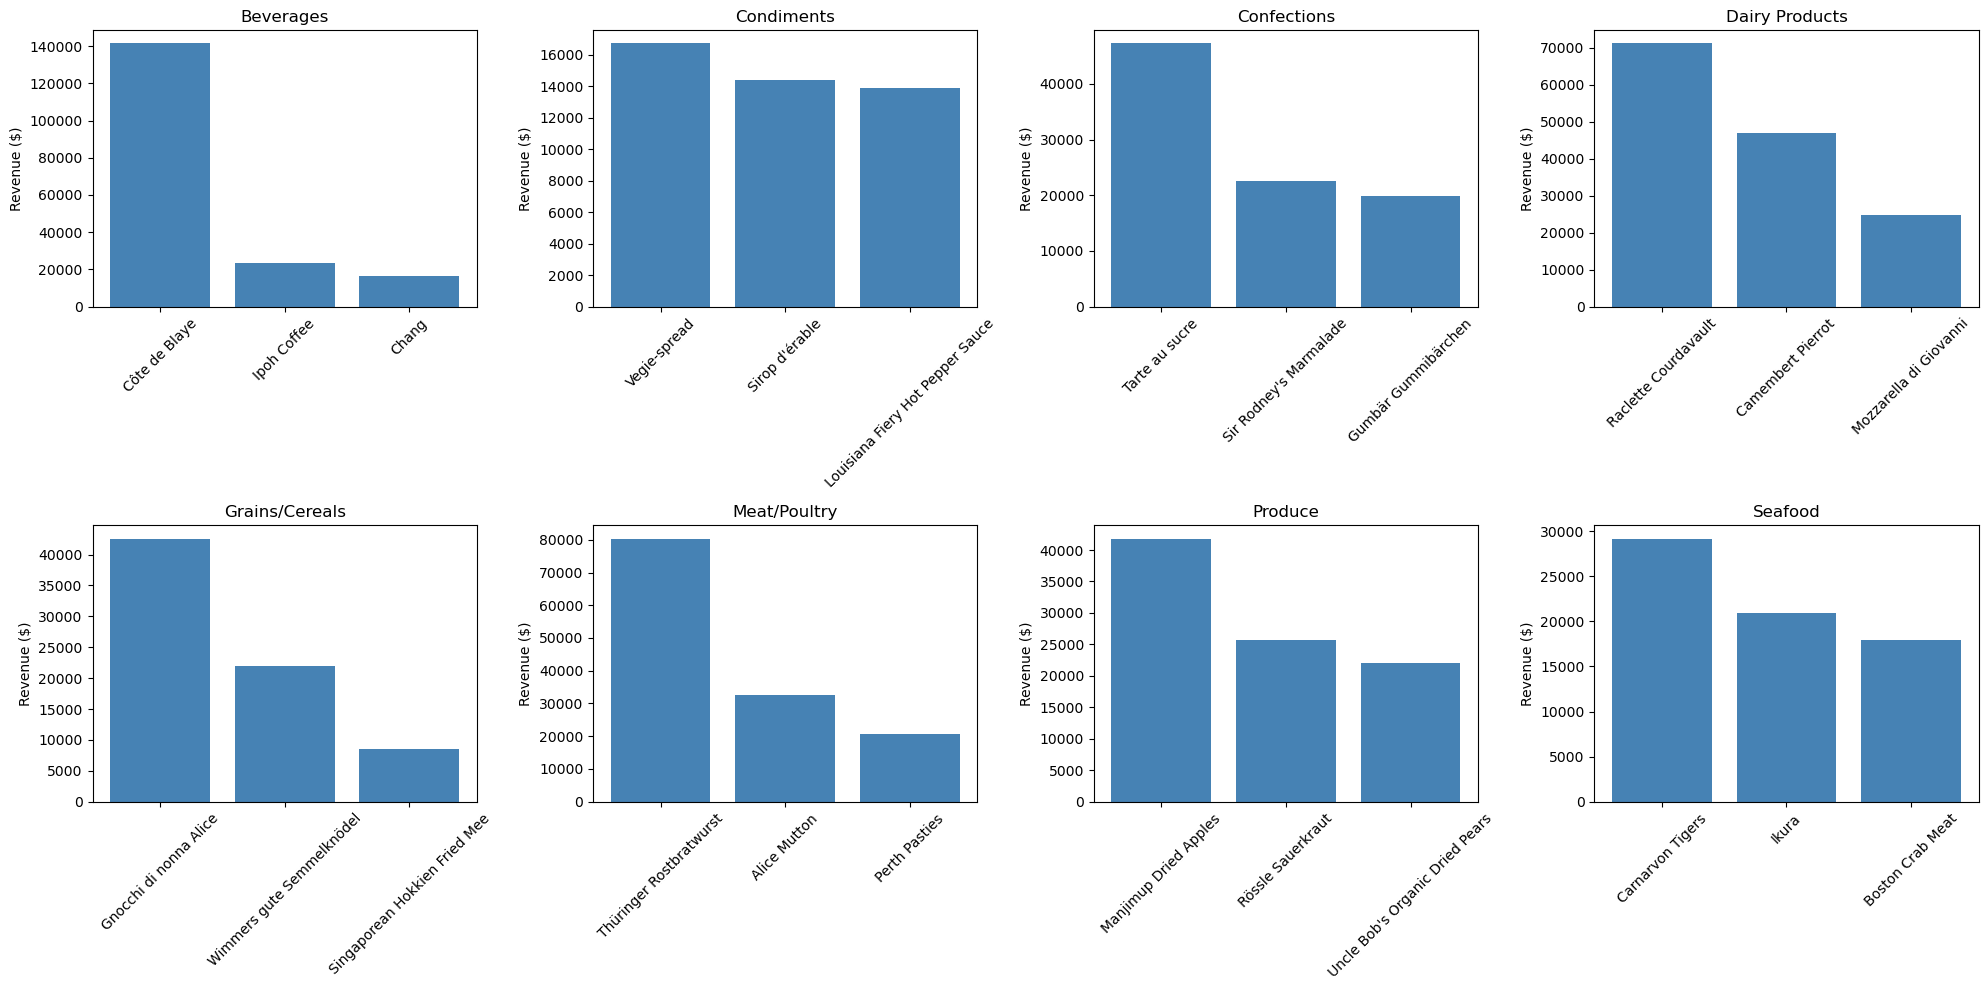

In [36]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()  # turns the 2x4 grid into a flat list of 8, easier to loop over

for i, cat in enumerate(categories):
    subset = df_top3[df_top3['CategoryName'] == cat]
    axes[i].bar(subset['ProductName'], subset['ProductRevenue'], color='steelblue')
    axes[i].set_title(cat)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.savefig('top3_products_per_category.png', dpi=150)
plt.show()